In [1]:
# ✅ Cell 1 — Safe Setup (Installs + Credentials + Drive Mount)

# ---------- Install packages ----------
!pip install -q kaggle seaborn pandas scikit-learn streamlit joblib matplotlib openpyxl

# ---------- Mount Google Drive ----------
from google.colab import drive
drive.mount('/content/drive')

# ---------- Load Kaggle credentials SAFELY from Colab Secrets ----------
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"]      = userdata.get('KAGGLE_KEY')

print("✅ Setup complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 25.6 MB/s eta 0:00:00
Mounted at /content/drive
✅ Setup complete!


In [2]:
# ✅ Cell 2 — Download Dataset from Kaggle

# Create folder to store data
!mkdir -p /content/ecom_data

# Download and unzip the dataset
!kaggle datasets download -d ajinkyachintawar/sales-and-customer-behaviour-insights \
    -p /content/ecom_data --unzip

# Check what files we got
!ls -l /content/ecom_data

Dataset URL: https://www.kaggle.com/datasets/ajinkyachintawar/sales-and-customer-behaviour-insights
License(s): CC0-1.0
100% 55.8k/55.8k [00:00<00:00, 1.22MB/s]

total 240
-rw-r--r-- 1 root root  28989 Apr 13 07:08 customer_info.csv
-rw-r--r-- 1 root root   1750 Apr 13 07:08 product_info.csv
-rw-r--r-- 1 root root 208149 Apr 13 07:08 sales_data.csv


In [3]:
# ✅ Cell 3 — Load Data & Understand Its Structure

import pandas as pd

base_path = "/content/ecom_data"

# Load all three files
customers = pd.read_csv(f"{base_path}/customer_info.csv")
products  = pd.read_csv(f"{base_path}/product_info.csv")
sales     = pd.read_csv(f"{base_path}/sales_data.csv")

# ---------- Shape (rows, columns) ----------
print("=== DATA SHAPES ===")
print(f"Sales     : {sales.shape[0]} rows, {sales.shape[1]} columns")
print(f"Customers : {customers.shape[0]} rows, {customers.shape[1]} columns")
print(f"Products  : {products.shape[0]} rows, {products.shape[1]} columns")

# ---------- Column names ----------
print("\n=== COLUMN NAMES ===")
print("Sales columns     :", list(sales.columns))
print("Customer columns  :", list(customers.columns))
print("Product columns   :", list(products.columns))

# ---------- First 3 rows of sales ----------
print("\n=== SALES SAMPLE (first 3 rows) ===")
print(sales.head(3))

# ---------- Missing values ----------
print("\n=== MISSING VALUES ===")
print("Sales missing:\n",     sales.isnull().sum())
print("\nCustomers missing:\n", customers.isnull().sum())
print("\nProducts missing:\n",  products.isnull().sum())

# ---------- Data types ----------
print("\n=== SALES DATA TYPES ===")
print(sales.dtypes)

=== DATA SHAPES ===
Sales     : 3000 rows, 10 columns
Customers : 500 rows, 6 columns
Products  : 30 rows, 6 columns

=== COLUMN NAMES ===
Sales columns     : ['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'delivery_status', 'payment_method', 'region', 'discount_applied']
Customer columns  : ['customer_id', 'email', 'signup_date', 'gender', 'region', 'loyalty_tier']
Product columns   : ['product_id', 'product_name', 'category', 'launch_date', 'base_price', 'supplier_code']

=== SALES SAMPLE (first 3 rows) ===
  order_id customer_id product_id quantity  unit_price order_date  \
0  O966977      C00397      P0022        3       39.25   06-07-25   
1  O696648      C00236      P0023        5       18.92   06-07-25   
2  O202644      C00492      P0011        1       29.68   06-07-25   

  delivery_status payment_method   region  discount_applied  
0       Delivered         PayPal  Central              0.00  
1         DELAYED    credit card    North        

In [4]:
# ✅ Cell 4 — Data Cleaning

import pandas as pd
import numpy as np

# ---------- Step 1: Drop rows where key ID columns are missing ----------
# We can't use a sale if we don't know the order, customer, or product
sales = sales.dropna(subset=["order_id", "customer_id", "product_id"])

print(f"Sales rows after dropping missing IDs: {len(sales)}")

# ---------- Step 2: Fix quantity — convert text to number ----------
# pd.to_numeric() tries to convert each value to a number
# errors='coerce' means: if it can't convert, put NaN instead of crashing
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")

# Fill remaining NaN quantities with 1 (assume at least 1 item ordered)
sales["quantity"] = sales["quantity"].fillna(1).astype(int)

print(f"Quantity dtype after fix: {sales['quantity'].dtype}")

# ---------- Step 3: Fix order_date — convert text to proper date ----------
# format="%d-%m-%y" tells pandas exactly how the date string is structured
# 06-07-25 means day=06, month=07, year=2025
sales["order_date"] = pd.to_datetime(sales["order_date"], format="%d-%m-%y", errors="coerce")

# Drop rows where date couldn't be parsed
sales = sales.dropna(subset=["order_date"])

print(f"order_date dtype after fix: {sales['order_date'].dtype}")
print(f"Date range: {sales['order_date'].min()} to {sales['order_date'].max()}")

# ---------- Step 4: Fix discount_applied — fill missing with 0 ----------
# Logic: if discount is missing, assume no discount was applied
sales["discount_applied"] = sales["discount_applied"].fillna(0)

print(f"Missing discounts after fix: {sales['discount_applied'].isnull().sum()}")

# ---------- Step 5: Standardize delivery_status text ----------
# .str.strip() removes accidental spaces before/after text
# .str.lower() converts everything to lowercase
# so "Delivered", "delivered", " delivered " all become "delivered"
sales["delivery_status"] = sales["delivery_status"].str.strip().str.lower()

print(f"\nDelivery status unique values: {sales['delivery_status'].unique()}")

# ---------- Step 6: Create Revenue column ----------
# Revenue = how much money was made per order row
# We subtract the discount from the price first, then multiply by quantity
sales["revenue"] = sales["quantity"] * (sales["unit_price"] * (1 - sales["discount_applied"]))

print(f"\nRevenue column created ✅")
print(f"Total revenue: {sales['revenue'].sum():,.2f}")

# ---------- Final shape ----------
print(f"\nFinal cleaned sales shape: {sales.shape}")

Sales rows after dropping missing IDs: 2992
Quantity dtype after fix: int64
order_date dtype after fix: datetime64[ns]
Date range: 2025-07-06 00:00:00 to 2025-07-06 00:00:00
Missing discounts after fix: 0

Delivery status unique values: ['delivered' 'delayed' 'cancelled' 'delrd' 'delyd' nan]

Revenue column created ✅
Total revenue: 239,270.39

Final cleaned sales shape: (2989, 11)


In [5]:
# ✅ Cell 4b — Fix Dirty Delivery Status Values

# ---------- Step 1: Map typos to correct values ----------
# We create a dictionary that says "if you see THIS, replace with THAT"
# This is called mapping — very common in real data cleaning

delivery_fix = {
    "delrd" : "delivered",   # typo for delivered
    "delyd" : "delayed",     # typo for delayed
}

# .replace() on a Series uses the dictionary to swap values
sales["delivery_status"] = sales["delivery_status"].replace(delivery_fix)

# ---------- Step 2: Fill remaining NaN with "unknown" ----------
# We don't drop these rows — the sale still happened, we just don't know delivery status
sales["delivery_status"] = sales["delivery_status"].fillna("unknown")

# ---------- Step 3: Verify ----------
print("Delivery status values after fix:")
print(sales["delivery_status"].value_counts())

print(f"\nAny missing left: {sales['delivery_status'].isnull().sum()}")

Delivery status values after fix:
delivery_status
delivered    1228
delayed      1170
cancelled     588
unknown         3
Name: count, dtype: int64

Any missing left: 0


In [6]:
# ✅ Cell 5 — Merge All Three Tables Into One Master DataFrame

# ---------- Step 1: Merge sales with customers ----------
# how="left" means: keep ALL rows from sales
# even if a customer_id in sales has no match in customers
# those unmatched rows will just have NaN for customer columns
df = sales.merge(customers, on="customer_id", how="left")

print(f"After merging sales + customers: {df.shape}")

# ---------- Step 2: Merge result with products ----------
df = df.merge(products, on="product_id", how="left")

print(f"After merging with products: {df.shape}")

# ---------- Step 3: Quick check — see all columns now ----------
print(f"\nAll columns in merged dataframe:")
print(list(df.columns))

# ---------- Step 4: Handle duplicate column names ----------
# Both sales and customers have a 'region' column
# After merge, pandas renames them region_x (from sales) and region_y (from customers)
# We keep region_x (sales region) and drop region_y
if "region_x" in df.columns:
    df = df.rename(columns={"region_x": "region"})
    df = df.drop(columns=["region_y"])
    print(f"\nFixed duplicate region columns ✅")

# ---------- Step 5: Final check ----------
print(f"\nFinal merged dataframe shape: {df.shape}")
print(f"\nSample row:")
print(df.iloc[0])

After merging sales + customers: (2989, 16)
After merging with products: (2989, 21)

All columns in merged dataframe:
['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'delivery_status', 'payment_method', 'region_x', 'discount_applied', 'revenue', 'email', 'signup_date', 'gender', 'region_y', 'loyalty_tier', 'product_name', 'category', 'launch_date', 'base_price', 'supplier_code']

Fixed duplicate region columns ✅

Final merged dataframe shape: (2989, 20)

Sample row:
order_id                                     O966977
customer_id                                   C00397
product_id                                     P0022
quantity                                           3
unit_price                                     39.25
order_date                       2025-07-06 00:00:00
delivery_status                            delivered
payment_method                                PayPal
region                                       Central
discount_applied  

In [8]:
# ✅ Cell 6b — Fix Remaining Dirty Categorical Values

# ============================================================
# WHY WE DO THIS:
# Groupby treats "GOLD", "gold", "gld" as 3 different groups
# This splits your revenue across fake categories
# We need to standardize everything to one clean value
# ============================================================

# ---------- Step 1: Standardize loyalty_tier ----------
# First lowercase + strip everything, then map known typos
df["loyalty_tier"] = df["loyalty_tier"].str.strip().str.lower()

loyalty_fix = {
    "gld"   : "gold",
    "brnze" : "bronze",
    "sllver": "silver",
}
df["loyalty_tier"] = df["loyalty_tier"].replace(loyalty_fix)

print("Loyalty tier after fix:")
print(df["loyalty_tier"].value_counts())

# ---------- Step 2: Standardize gender ----------
df["gender"] = df["gender"].str.strip().str.lower()

gender_fix = {
    "femle" : "female",
    "mal"   : "male",
}
df["gender"] = df["gender"].replace(gender_fix)

print("\nGender after fix:")
print(df["gender"].value_counts())

# ---------- Step 3: Standardize region ----------
df["region"] = df["region"].str.strip().str.lower()

region_fix = {
    "nrth"    : "north",
    "sth"     : "south",
    "est"     : "east",
    "wst"     : "west",
    "cntrl"   : "central",
}
df["region"] = df["region"].replace(region_fix)

print("\nRegion after fix:")
print(df["region"].value_counts())

# ---------- Step 4: Standardize payment_method ----------
df["payment_method"] = df["payment_method"].str.strip().str.lower()

payment_fix = {
    "bank transfr" : "bank transfer",
    "cc"           : "credit card",
}
df["payment_method"] = df["payment_method"].replace(payment_fix)

print("\nPayment method after fix:")
print(df["payment_method"].value_counts())

print("\n✅ All categorical columns cleaned!")

Loyalty tier after fix:
loyalty_tier
gold      1673
silver     660
bronze     623
Name: count, dtype: int64

Gender after fix:
gender
female    1459
male      1018
other      470
Name: count, dtype: int64

Region after fix:
region
north      605
central    600
east       600
south      595
west       589
Name: count, dtype: int64

Payment method after fix:
payment_method
credit card      1449
bank transfer     778
paypal            759
Name: count, dtype: int64

✅ All categorical columns cleaned!


/tmp/ipykernel_2932/3939516143.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_rev.index, y=region_rev.values, palette="viridis")


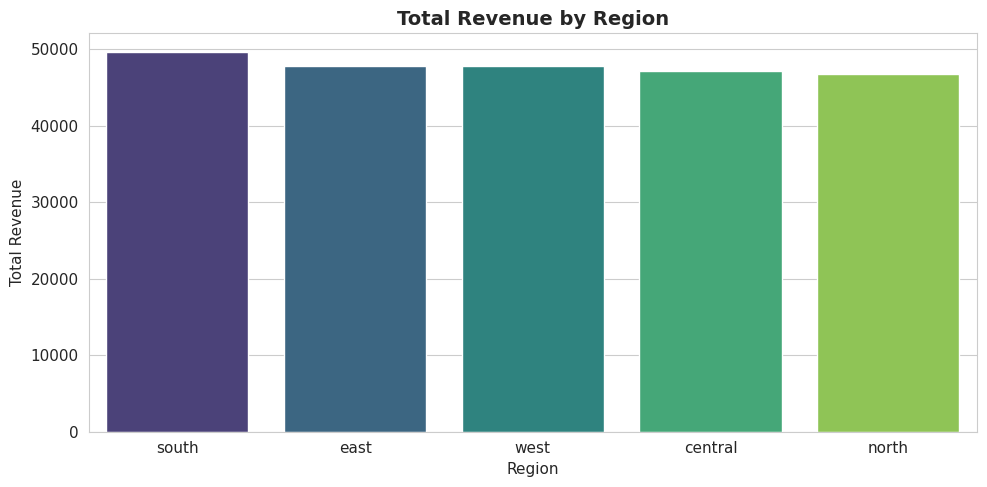

Revenue by Region:
region
south      49617.73
east       47856.23
west       47789.19
central    47186.87
north      46820.37
Name: revenue, dtype: float64


/tmp/ipykernel_2932/3939516143.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.values, y=cat_rev.index, palette="magma")


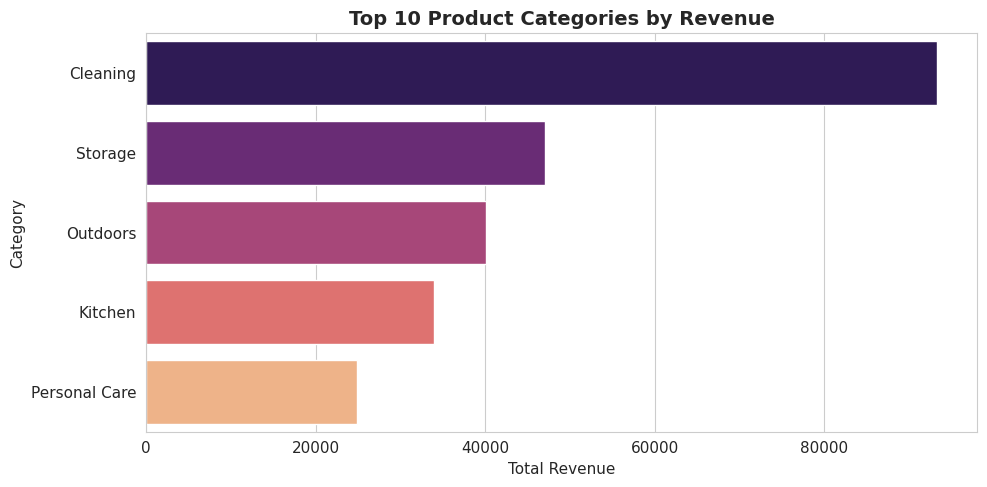


Top 10 Categories:
category
Cleaning         93314.04
Storage          47010.48
Outdoors         40060.56
Kitchen          33993.04
Personal Care    24892.28
Name: revenue, dtype: float64


/tmp/ipykernel_2932/3939516143.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loyalty_rev.index, y=loyalty_rev.values, palette="coolwarm")


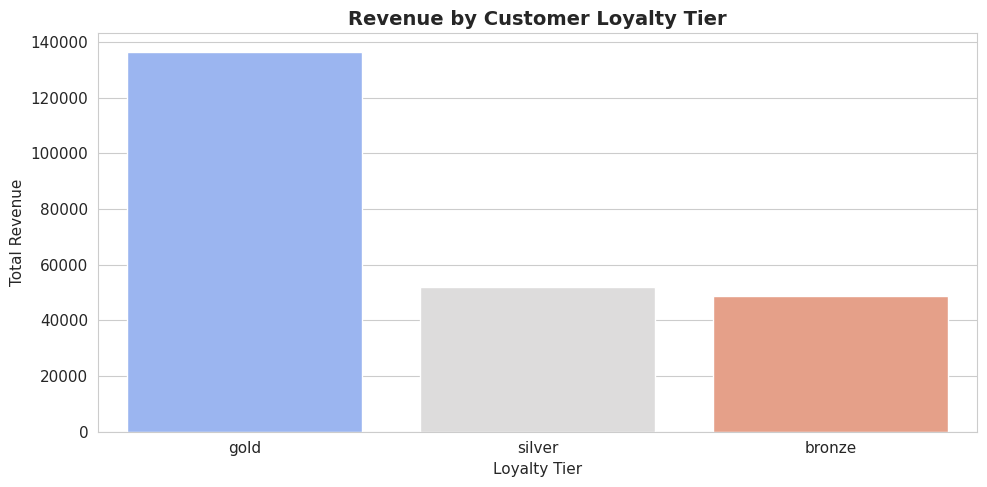


Revenue by Loyalty Tier:
loyalty_tier
gold      136302.70
silver     52111.63
bronze     48763.44
Name: revenue, dtype: float64


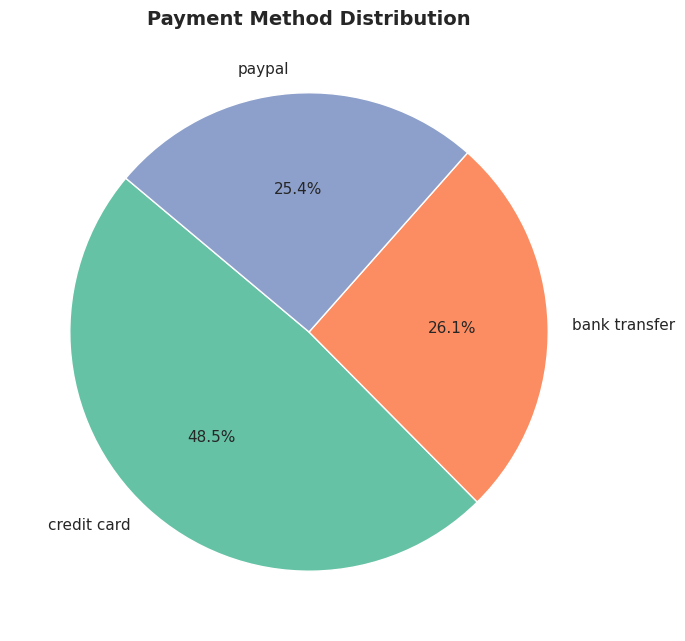


Payment Methods:
payment_method
credit card      1449
bank transfer     778
paypal            759
Name: count, dtype: int64


/tmp/ipykernel_2932/3939516143.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_counts.index, y=delivery_counts.values, palette="Set1")


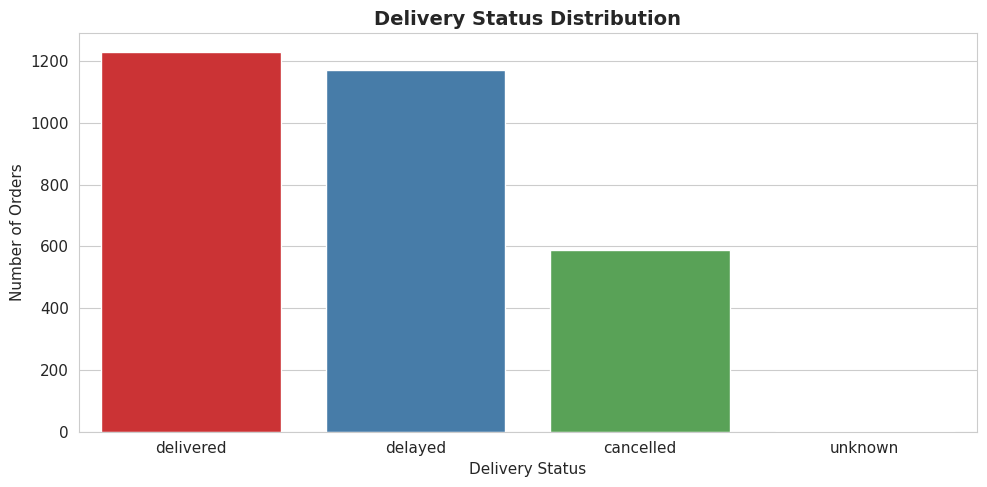


Delivery Status Counts:
delivery_status
delivered    1228
delayed      1170
cancelled     588
unknown         3
Name: count, dtype: int64


/tmp/ipykernel_2932/3939516143.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_rev.index, y=gender_rev.values, palette="pastel")


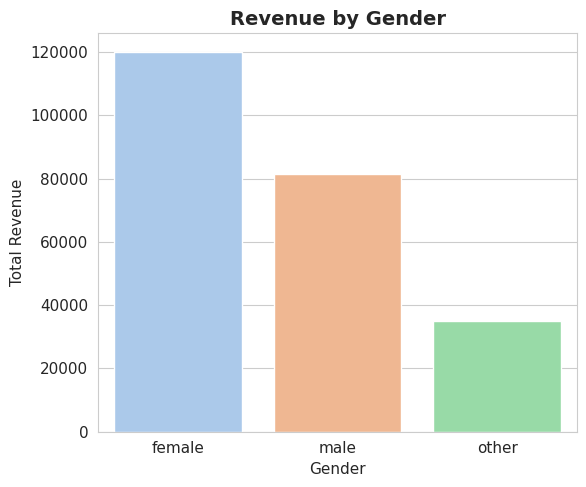


Revenue by Gender:
gender
female    119914.35
male       81598.97
other      35032.58
Name: revenue, dtype: float64

✅ All EDA plots saved!


In [9]:
# ✅ Cell 6 — Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# ============================================================
# PLOT 1 — Revenue by Region
# Business question: Which region generates most revenue?
# ============================================================
region_rev = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=region_rev.index, y=region_rev.values, palette="viridis")
plt.title("Total Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("/content/ecom_data/region_revenue.png", dpi=150)
plt.show()
print("Revenue by Region:")
print(region_rev.round(2))

# ============================================================
# PLOT 2 — Top 10 Product Categories by Revenue
# Business question: Which categories should we stock more of?
# ============================================================
cat_rev = df.groupby("category")["revenue"].sum()\
            .sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette="magma")
plt.title("Top 10 Product Categories by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("/content/ecom_data/top_categories.png", dpi=150)
plt.show()
print("\nTop 10 Categories:")
print(cat_rev.round(2))

# ============================================================
# PLOT 3 — Revenue by Customer Loyalty Tier
# Business question: Do loyal customers spend more?
# ============================================================
loyalty_rev = df.groupby("loyalty_tier")["revenue"].sum()\
                .sort_values(ascending=False)

plt.figure()
sns.barplot(x=loyalty_rev.index, y=loyalty_rev.values, palette="coolwarm")
plt.title("Revenue by Customer Loyalty Tier", fontsize=14, fontweight="bold")
plt.xlabel("Loyalty Tier")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("/content/ecom_data/loyalty_revenue.png", dpi=150)
plt.show()
print("\nRevenue by Loyalty Tier:")
print(loyalty_rev.round(2))

# ============================================================
# PLOT 4 — Payment Method Distribution
# Business question: How do customers prefer to pay?
# ============================================================
payment_counts = df["payment_method"].str.strip().str.lower()\
                   .value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",       # shows percentage on each slice
    startangle=140,
    colors=sns.color_palette("Set2")
)
plt.title("Payment Method Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/ecom_data/payment_methods.png", dpi=150)
plt.show()
print("\nPayment Methods:")
print(payment_counts)

# ============================================================
# PLOT 5 — Delivery Status Distribution
# Business question: How reliable is delivery?
# ============================================================
delivery_counts = df["delivery_status"].value_counts()

plt.figure()
sns.barplot(x=delivery_counts.index, y=delivery_counts.values, palette="Set1")
plt.title("Delivery Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("/content/ecom_data/delivery_status.png", dpi=150)
plt.show()
print("\nDelivery Status Counts:")
print(delivery_counts)

# ============================================================
# PLOT 6 — Revenue by Gender
# Business question: Is there a spending difference by gender?
# ============================================================
gender_rev = df.groupby("gender")["revenue"].sum()\
               .sort_values(ascending=False)

plt.figure(figsize=(6, 5))
sns.barplot(x=gender_rev.index, y=gender_rev.values, palette="pastel")
plt.title("Revenue by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("/content/ecom_data/gender_revenue.png", dpi=150)
plt.show()
print("\nRevenue by Gender:")
print(gender_rev.round(2))

print("\n✅ All EDA plots saved!")

Snapshot date: 2025-07-07

RFM table shape: (499, 4)

RFM sample:
  customer_id  frequency  monetary  recency
0      C00001          8  682.8015        1
1      C00002          7  552.7430        1
2      C00003          3  234.3170        1
3      C00004          5  349.5790        1
4      C00005          5  174.4420        1

RFM Statistics:
       recency  frequency  monetary
count    499.0     499.00    499.00
mean       1.0       5.99    479.50
std        0.0       2.44    247.27
min        1.0       1.00     16.01
25%        1.0       4.00    306.69
50%        1.0       6.00    434.60
75%        1.0       7.00    628.99
max        1.0      15.00   1546.47
⚠️ Note: All orders on same date — recency score set to 3 for all customers.
   This is a dataset limitation, not a code error.

Customer Segments:
segment
Loyal Customers        272
Potential Loyalists    227
Name: count, dtype: int64


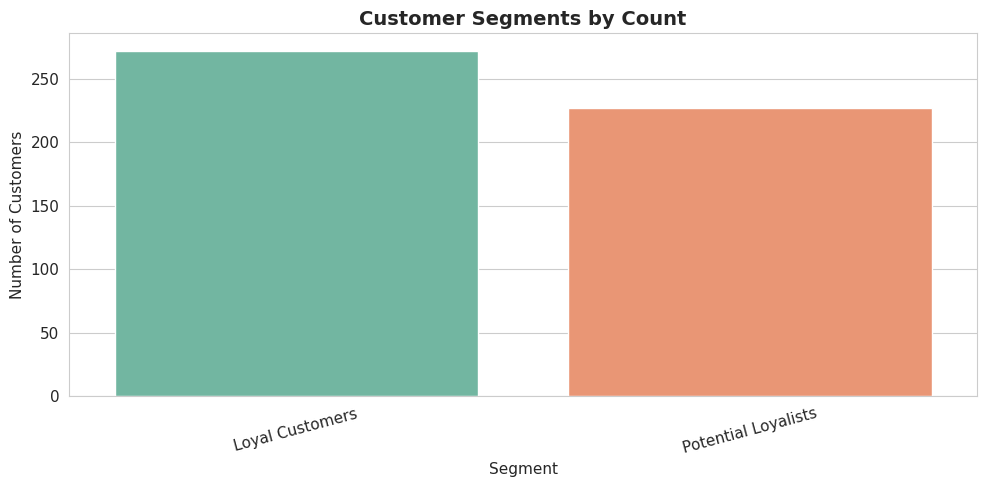


Segment Summary (averages):
                     recency  frequency  monetary
segment                                          
Loyal Customers          1.0       7.74    625.68
Potential Loyalists      1.0       3.89    304.34

✅ RFM analysis complete! rfm_summary.csv saved.


In [12]:
# ✅ Cell 7 — RFM Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 1: Build RFM table — one row per customer
# ============================================================

# snapshot_date = the "today" we measure recency from
# We use the max order date in our data + 1 day
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Group by customer and calculate R, F, M
rfm = df.groupby("customer_id").agg(
    last_order_date = ("order_date", "max"),      # most recent purchase date
    frequency       = ("order_id",  "nunique"),   # number of unique orders
    monetary        = ("revenue",   "sum")         # total revenue from customer
).reset_index()

# Recency = how many days since last purchase
rfm["recency"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Drop the date column — we only need the number
rfm = rfm.drop(columns=["last_order_date"])

print(f"\nRFM table shape: {rfm.shape}")
print(f"\nRFM sample:")
print(rfm.head())

print(f"\nRFM Statistics:")
print(rfm[["recency","frequency","monetary"]].describe().round(2))

# ============================================================
# STEP 2: Score each customer 1–5 on R, F, M
# ============================================================

# WHY SCORES?
# Raw numbers are hard to compare across customers
# Scores put everyone on the same 1-5 scale

# pd.qcut() splits data into 5 equal-sized buckets (quintiles)
# For Recency: lower days = better = score 5
# labels=[5,4,3,2,1] means smallest recency gets score 5
# ============================================================
# STEP 2: Score each customer 1–5 on R, F, M
# ============================================================

# --- Recency Score ---
# Special case: if all recency values are the same
# (happens when all orders are on the same date)
# we assign everyone score 3 (neutral) and note the limitation
if rfm["recency"].nunique() == 1:
    rfm["r_score"] = 3
    print("⚠️ Note: All orders on same date — recency score set to 3 for all customers.")
    print("   This is a dataset limitation, not a code error.")
else:
    rfm["r_score"] = pd.qcut(
        rfm["recency"],
        q=5,
        labels=[5, 4, 3, 2, 1],
        duplicates="drop"
    ).astype(int)

# --- Frequency Score ---
# Higher frequency = better = score 5
rfm["f_score"] = pd.qcut(
    rfm["frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

# --- Monetary Score ---
# Higher spending = better = score 5
rfm["m_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

# Combine into one RFM score string e.g. "355"
rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

# ============================================================
# STEP 3: Assign human-readable segment labels
# ============================================================

# WHY LABELS?
# "555" is technical — "Champion" is what a manager understands
# This bridges data science and business communication

def assign_segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"           # buy often, recently, spend a lot
    elif r >= 3 and f >= 3:
        return "Loyal Customers"     # buy regularly
    elif r >= 4 and f <= 2:
        return "New Customers"       # bought recently but not often yet
    elif r <= 2 and f >= 3:
        return "At Risk"             # used to buy often but not recently
    elif r <= 2 and f <= 2:
        return "Lost"                # haven't bought recently, low frequency
    else:
        return "Potential Loyalists" # in between — could go either way

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print(f"\nCustomer Segments:")
print(rfm["segment"].value_counts())

# ============================================================
# STEP 4: Visualize segments
# ============================================================

seg_counts = rfm["segment"].value_counts()

plt.figure(figsize=(10, 5))
# NEW — correct modern seaborn syntax
sns.barplot(
    x=seg_counts.index,
    y=seg_counts.values,
    hue=seg_counts.index,   # assign x to hue
    palette="Set2",
    legend=False             # hide redundant legend
)
plt.title("Customer Segments by Count", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/ecom_data/rfm_segments.png", dpi=150)
plt.show()

# ============================================================
# STEP 5: Average RFM values per segment
# ============================================================

seg_summary = rfm.groupby("segment")[["recency","frequency","monetary"]]\
                 .mean().round(2)

print(f"\nSegment Summary (averages):")
print(seg_summary)

# Save RFM table for Streamlit app
rfm.to_csv("/content/ecom_data/rfm_summary.csv", index=False)
print("\n✅ RFM analysis complete! rfm_summary.csv saved.")

=== CHURN DISTRIBUTION ===
churn
0    489
1     10
Name: count, dtype: int64

Churn rate: 2.0%

=== CLASS BALANCE ===
Not Churned (0): 489 (98.0%)
Churned     (1): 10 (2.0%)

⚠️  Imbalanced dataset detected!
   We will use class_weight='balanced' to handle this.

=== TRAIN/TEST SPLIT ===
Training samples : 399
Testing samples  : 100

✅ Features scaled successfully

=== MODEL 1: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

 Not Churned       1.00      0.95      0.97        98
     Churned       0.29      1.00      0.44         2

    accuracy                           0.95       100
   macro avg       0.64      0.97      0.71       100
weighted avg       0.99      0.95      0.96       100

ROC-AUC Score: 1.000

=== MODEL 2: RANDOM FOREST ===
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00        98
     Churned       1.00      1.00      1.00         2

    accuracy                           1.00       1

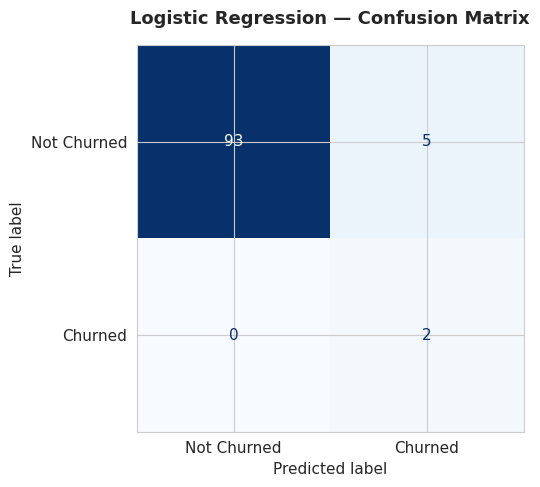

✅ Logistic Regression confusion matrix saved


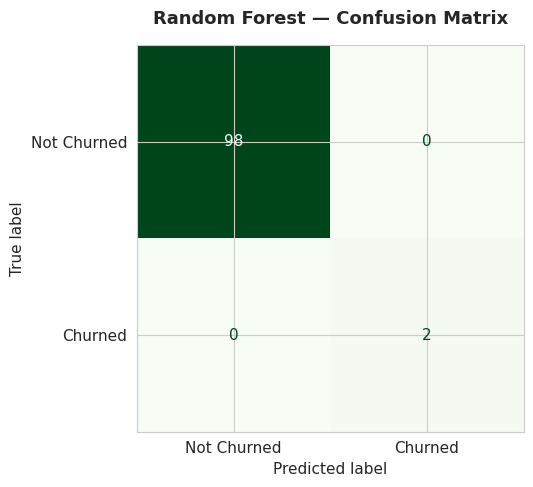

✅ Random Forest confusion matrix saved


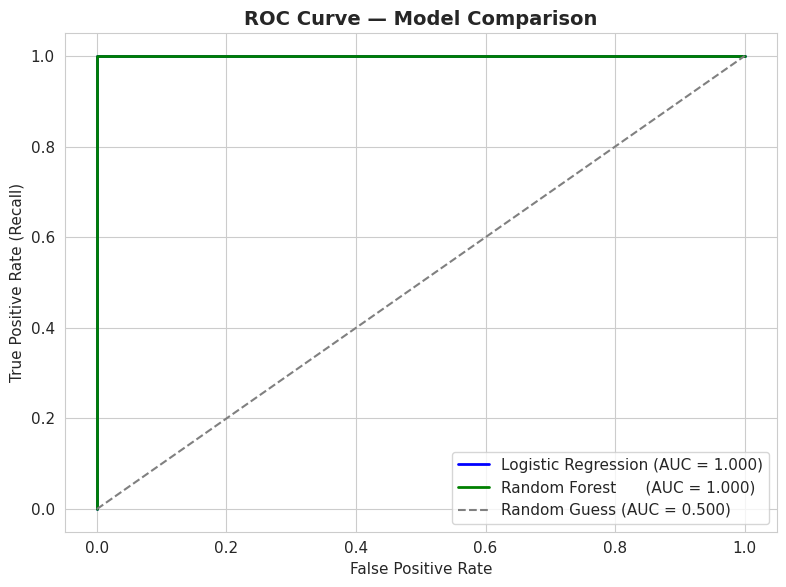

✅ ROC curve saved


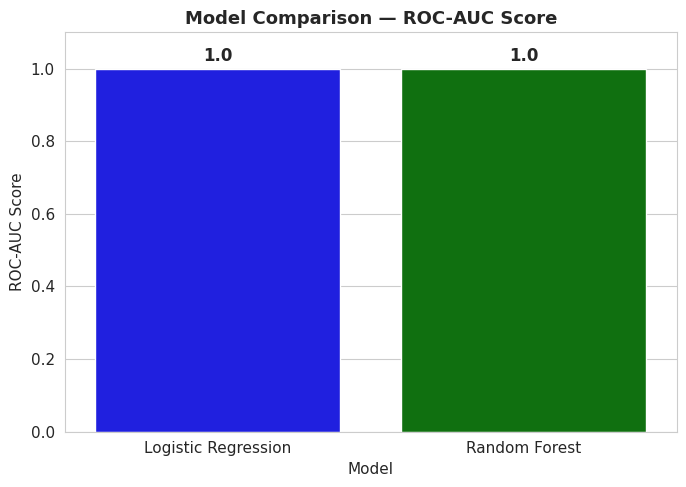

✅ Model comparison chart saved

✅ All evaluation charts saved separately!


In [14]:
# ✅ Cell 8 — Churn Prediction With Proper Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
import joblib

# ============================================================
# STEP 1: Define Churn
# ============================================================

# Churn = 1 if customer only ordered once (never returned)
# Churn = 0 if customer ordered more than once (returning customer)
rfm["churn"] = (rfm["frequency"] == 1).astype(int)

print("=== CHURN DISTRIBUTION ===")
churn_counts = rfm["churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {rfm['churn'].mean()*100:.1f}%")

# ============================================================
# STEP 2: Check Class Imbalance
# ============================================================

# WHY CHECK THIS?
# If 95% of customers are non-churners, a model that always says
# "not churned" gets 95% accuracy but is completely useless
# We need to know the balance before trusting any accuracy number

total = len(rfm)
churned = rfm["churn"].sum()
not_churned = total - churned

print(f"\n=== CLASS BALANCE ===")
print(f"Not Churned (0): {not_churned} ({not_churned/total*100:.1f}%)")
print(f"Churned     (1): {churned} ({churned/total*100:.1f}%)")

if churned/total < 0.2:
    print("\n⚠️  Imbalanced dataset detected!")
    print("   We will use class_weight='balanced' to handle this.")
else:
    print("\n✅ Classes are reasonably balanced.")

# ============================================================
# STEP 3: Prepare Features and Target
# ============================================================

# Features (X) = what the model uses to make predictions
# Target  (y) = what we want to predict (churn or not)

# We use frequency and monetary as features
# We do NOT use recency because it's the same for everyone (dataset limitation)
X = rfm[["frequency", "monetary"]]
y = rfm["churn"]

# Split into training set (80%) and test set (20%)
# WHY SPLIT?
# We train on 80% of data, then test on the remaining 20%
# The model has never seen the test data — so it's a fair evaluation
# stratify=y ensures both sets have same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n=== TRAIN/TEST SPLIT ===")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# ============================================================
# STEP 4: Scale Features
# ============================================================

# WHY SCALE?
# frequency ranges from 1-15, monetary ranges from 16-1546
# Logistic Regression is sensitive to scale differences
# StandardScaler makes both features have mean=0 and std=1
# Random Forest doesn't need scaling but it doesn't hurt either

scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then transform both
# If you fit on all data, you're leaking test information into training
# This is called data leakage — a serious mistake in ML
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only, no fit

print("\n✅ Features scaled successfully")

# ============================================================
# STEP 5: Train Model 1 — Logistic Regression (Baseline)
# ============================================================

# WHY LOGISTIC REGRESSION FIRST?
# Always start with the simplest model as a baseline
# If your complex model can't beat a simple one, something is wrong
# class_weight='balanced' handles imbalance automatically

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)
lr.fit(X_train_scaled, y_train)
lr_preds  = lr.predict(X_test_scaled)
lr_proba  = lr.predict_proba(X_test_scaled)[:, 1]  # probability of churn

print("\n=== MODEL 1: LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_preds,
      target_names=["Not Churned", "Churned"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.3f}")

# ============================================================
# STEP 6: Train Model 2 — Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== MODEL 2: RANDOM FOREST ===")
print(classification_report(y_test, rf_preds,
      target_names=["Not Churned", "Churned"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.3f}")

# ============================================================
# STEP 7: Visual Evaluation — Confusion Matrices
# ============================================================

# WHAT IS A CONFUSION MATRIX?
# It shows 4 things:
# True Positives  (TP): correctly predicted churn
# True Negatives  (TN): correctly predicted not churn
# False Positives (FP): predicted churn but was wrong
# False Negatives (FN): missed a churner — most costly mistake

# ✅ Cell 8b — Save Confusion Matrices as Separate Images

# ---------- Logistic Regression Confusion Matrix ----------
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_preds),
    display_labels=["Not Churned", "Churned"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("/content/ecom_data/cm_logistic.png", dpi=150)
plt.show()
print("✅ Logistic Regression confusion matrix saved")

# ---------- Random Forest Confusion Matrix ----------
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=["Not Churned", "Churned"]
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Random Forest — Confusion Matrix",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("/content/ecom_data/cm_random_forest.png", dpi=150)
plt.show()
print("✅ Random Forest confusion matrix saved")

# ---------- ROC Curve ----------
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_fpr, lr_tpr,
        label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})",
        color="blue", linewidth=2)
ax.plot(rf_fpr, rf_tpr,
        label=f"Random Forest      (AUC = {roc_auc_score(y_test, rf_proba):.3f})",
        color="green", linewidth=2)
ax.plot([0,1], [0,1],
        linestyle="--", color="gray", label="Random Guess (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Model Comparison",
             fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/content/ecom_data/roc_curve.png", dpi=150)
plt.show()
print("✅ ROC curve saved")

# ---------- Model Comparison Bar Chart ----------
comparison = pd.DataFrame({
    "Model"  : ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        round(roc_auc_score(y_test, lr_proba), 3),
        round(roc_auc_score(y_test, rf_proba), 3)
    ]
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=comparison,
    x="Model",
    y="ROC-AUC",
    hue="Model",
    palette=["blue", "green"],
    legend=False,
    ax=ax
)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — ROC-AUC Score",
             fontsize=13, fontweight="bold")
ax.set_ylabel("ROC-AUC Score")

# Add value labels on top of bars
for i, row in comparison.iterrows():
    ax.text(i, row["ROC-AUC"] + 0.02,
            str(row["ROC-AUC"]),
            ha="center", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("/content/ecom_data/model_comparison.png", dpi=150)
plt.show()
print("✅ Model comparison chart saved")

print("\n✅ All evaluation charts saved separately!")

In [15]:
# ✅ Cell 9 — KPI Summary + Save All Files to Google Drive

import pandas as pd
import os

# ============================================================
# STEP 1: Calculate KPIs
# ============================================================

# Total Revenue — sum of all order revenues
total_revenue = df["revenue"].sum()

# Total Orders — count of unique order IDs
total_orders = df["order_id"].nunique()

# Total Customers — count of unique customers
total_customers = df["customer_id"].nunique()

# Average Order Value — average revenue per order
avg_order_value = df.groupby("order_id")["revenue"].sum().mean()

# Churn Rate — percentage of customers who churned
churn_rate = rfm["churn"].mean() * 100

# Average Orders Per Customer
avg_orders_per_customer = rfm["frequency"].mean()

# Top Region by Revenue
top_region = df.groupby("region")["revenue"].sum().idxmax()

# Top Category by Revenue
top_category = df.groupby("category")["revenue"].sum().idxmax()

# Delivery Success Rate — percentage of delivered orders
delivered = (df["delivery_status"] == "delivered").sum()
delivery_rate = (delivered / len(df)) * 100

# Average Discount Applied (only on orders that had a discount)
avg_discount = df[df["discount_applied"] > 0]["discount_applied"].mean() * 100

print("=== KPI SUMMARY ===")
print(f"Total Revenue          : {total_revenue:,.2f}")
print(f"Total Orders           : {total_orders:,}")
print(f"Total Customers        : {total_customers:,}")
print(f"Avg Order Value        : {avg_order_value:,.2f}")
print(f"Churn Rate             : {churn_rate:.1f}%")
print(f"Avg Orders/Customer    : {avg_orders_per_customer:.1f}")
print(f"Top Region             : {top_region}")
print(f"Top Category           : {top_category}")
print(f"Delivery Success Rate  : {delivery_rate:.1f}%")
print(f"Avg Discount           : {avg_discount:.1f}%")

# ============================================================
# STEP 2: Save KPIs to CSV
# ============================================================

kpi_data = {
    "Metric": [
        "Total_Revenue",
        "Total_Orders",
        "Total_Customers",
        "Avg_Order_Value",
        "Churn_Rate",
        "Avg_Orders_Per_Customer",
        "Top_Region",
        "Top_Category",
        "Delivery_Success_Rate",
        "Avg_Discount"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        round(avg_order_value, 2),
        round(churn_rate, 1),
        round(avg_orders_per_customer, 1),
        top_region,
        top_category,
        round(delivery_rate, 1),
        round(avg_discount, 1)
    ]
}

kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv("/content/ecom_data/kpi_summary.csv", index=False)
print("\n✅ KPI summary saved!")

# ============================================================
# STEP 3: Verify all required files exist
# ============================================================

required_files = [
    "kpi_summary.csv",
    "rfm_summary.csv",
    "rfm_with_churn.csv",
    "sales_data.csv",
    "customer_info.csv",
    "product_info.csv",
    "region_revenue.png",
    "top_categories.png",
    "loyalty_revenue.png",
    "payment_methods.png",
    "delivery_status.png",
    "gender_revenue.png",
    "rfm_segments.png",
    "cm_logistic.png",
    "cm_random_forest.png",
    "roc_curve.png",
    "model_comparison.png",
    "churn_model.joblib",
    "churn_scaler.joblib",
]

print("\n=== FILE CHECK ===")
all_present = True
for f in required_files:
    path = f"/content/ecom_data/{f}"
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"{status} — {f}")
    if not exists:
        all_present = False

if all_present:
    print("\n✅ All files present! Ready to build Streamlit app.")
else:
    print("\n⚠️ Some files are missing. Re-run the cells that generate them.")

# ============================================================
# STEP 4: Save everything to Google Drive
# ============================================================

import shutil

drive_path = "/content/drive/MyDrive/ecommerce_project"
os.makedirs(drive_path, exist_ok=True)

# Copy entire ecom_data folder to Drive
for f in os.listdir("/content/ecom_data"):
    src = f"/content/ecom_data/{f}"
    dst = f"{drive_path}/{f}"
    shutil.copy2(src, dst)

print(f"\n✅ All files backed up to Google Drive at:")
print(f"   {drive_path}")
print(f"\nTotal files saved: {len(os.listdir(drive_path))}")

=== KPI SUMMARY ===
Total Revenue          : 239,270.39
Total Orders           : 2,987
Total Customers        : 499
Avg Order Value        : 80.10
Churn Rate             : 2.0%
Avg Orders/Customer    : 6.0
Top Region             : south
Top Category           : Cleaning
Delivery Success Rate  : 41.1%
Avg Discount           : 12.4%

✅ KPI summary saved!

=== FILE CHECK ===
✅ — kpi_summary.csv
✅ — rfm_summary.csv
✅ — rfm_with_churn.csv
✅ — sales_data.csv
✅ — customer_info.csv
✅ — product_info.csv
✅ — region_revenue.png
✅ — top_categories.png
✅ — loyalty_revenue.png
✅ — payment_methods.png
✅ — delivery_status.png
✅ — gender_revenue.png
✅ — rfm_segments.png
✅ — cm_logistic.png
✅ — cm_random_forest.png
✅ — roc_curve.png
✅ — model_comparison.png
✅ — churn_model.joblib
✅ — churn_scaler.joblib

✅ All files present! Ready to build Streamlit app.

✅ All files backed up to Google Drive at:
   /content/drive/MyDrive/ecommerce_project

Total files saved: 20


In [16]:
# ✅ Cell 10 — Write Streamlit App

app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import joblib
import os

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title="E-commerce Analytics Dashboard",
    page_icon="📦",
    layout="wide"
)

# ============================================================
# LOAD DATA
# ============================================================
base = "."

@st.cache_data
def load_data():
    kpi       = pd.read_csv(f"{base}/kpi_summary.csv")
    rfm       = pd.read_csv(f"{base}/rfm_summary.csv")
    rfm_churn = pd.read_csv(f"{base}/rfm_with_churn.csv")
    sales     = pd.read_csv(f"{base}/sales_data.csv")
    customers = pd.read_csv(f"{base}/customer_info.csv")
    return kpi, rfm, rfm_churn, sales, customers

kpi_df, rfm_df, rfm_churn_df, sales_df, customers_df = load_data()

# Helper to get a KPI value by name
def get_kpi(name):
    row = kpi_df.loc[kpi_df["Metric"] == name, "Value"]
    return row.values[0] if len(row) else "N/A"

# ============================================================
# HEADER
# ============================================================
st.title("📦 E-commerce Sales & Customer Analytics")
st.markdown("**Green Cart Ltd** — Interactive Business Intelligence Dashboard")
st.markdown("---")

# ============================================================
# TAB LAYOUT
# ============================================================
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 KPIs",
    "📈 Sales Analysis",
    "👥 RFM & Segments",
    "🤖 Model Evaluation"
])

# ============================================================
# TAB 1 — KPIs
# ============================================================
with tab1:
    st.subheader("Business Performance Overview")
    st.markdown("Key metrics summarising overall business health.")

    # Row 1 — Financial KPIs
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("💰 Total Revenue",
                f"{float(get_kpi('Total_Revenue')):,.0f} BDT")
    col2.metric("🛒 Total Orders",
                f"{int(float(get_kpi('Total_Orders'))):,}")
    col3.metric("👤 Total Customers",
                f"{int(float(get_kpi('Total_Customers'))):,}")
    col4.metric("🧾 Avg Order Value",
                f"{float(get_kpi('Avg_Order_Value')):,.2f} BDT")

    st.markdown("")

    # Row 2 — Operational KPIs
    col5, col6, col7, col8 = st.columns(4)
    col5.metric("📦 Delivery Success",
                f"{float(get_kpi('Delivery_Success_Rate')):.1f}%",
                delta="-58.9% orders delayed/cancelled",
                delta_color="inverse")
    col6.metric("🔄 Churn Rate",
                f"{float(get_kpi('Churn_Rate')):.1f}%")
    col7.metric("📋 Avg Orders/Customer",
                f"{float(get_kpi('Avg_Orders_Per_Customer')):.1f}")
    col8.metric("🏷️ Avg Discount",
                f"{float(get_kpi('Avg_Discount')):.1f}%")

    st.markdown("")

    # Row 3 — Top performers
    col9, col10 = st.columns(2)
    col9.info(f"🏆 **Top Region:** {str(get_kpi('Top_Region')).title()}")
    col10.info(f"🏆 **Top Category:** {str(get_kpi('Top_Category')).title()}")

    st.markdown("---")
    st.warning(
        "⚠️ **Key Business Alert:** Only 41.1% of orders are successfully "
        "delivered. 39.1% are delayed and 19.7% are cancelled. "
        "This is a critical operational issue requiring immediate attention."
    )

# ============================================================
# TAB 2 — SALES ANALYSIS
# ============================================================
with tab2:
    st.subheader("Sales Performance Analysis")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Revenue by Region**")
        img = Image.open(f"{base}/region_revenue.png")
        st.image(img, use_container_width=True)
        st.caption(
            "South leads slightly but all regions contribute similarly, "
            "suggesting no region-specific marketing is needed."
        )

    with col2:
        st.markdown("**Top 10 Categories by Revenue**")
        img = Image.open(f"{base}/top_categories.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Cleaning products generate nearly 2x more revenue than "
            "any other category. Priority stocking recommended."
        )

    col3, col4 = st.columns(2)

    with col3:
        st.markdown("**Revenue by Loyalty Tier**")
        img = Image.open(f"{base}/loyalty_revenue.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Gold customers generate 3x more revenue than Silver or Bronze. "
            "Loyalty program is clearly driving high-value behaviour."
        )

    with col4:
        st.markdown("**Payment Method Distribution**")
        img = Image.open(f"{base}/payment_methods.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Credit card dominates at 48%. All three methods are active "
            "so supporting all payment options is important."
        )

    col5, col6 = st.columns(2)

    with col5:
        st.markdown("**Delivery Status Distribution**")
        img = Image.open(f"{base}/delivery_status.png")
        st.image(img, use_container_width=True)
        st.caption(
            "⚠️ Critical finding: 59% of orders are delayed or cancelled. "
            "Immediate logistics review recommended."
        )

    with col6:
        st.markdown("**Revenue by Gender**")
        img = Image.open(f"{base}/gender_revenue.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Female customers generate significantly more revenue (119K) "
            "vs male (81K). Consider gender-targeted campaigns."
        )

# ============================================================
# TAB 3 — RFM & SEGMENTS
# ============================================================
with tab3:
    st.subheader("Customer Segmentation — RFM Analysis")
    st.markdown(
        "RFM stands for **Recency, Frequency, Monetary**. "
        "Each customer is scored on these three dimensions "
        "to identify their value and behaviour pattern."
    )

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Customer Segments**")
        img = Image.open(f"{base}/rfm_segments.png")
        st.image(img, use_container_width=True)
        st.caption(
            "272 Loyal Customers vs 227 Potential Loyalists. "
            "Focus retention efforts on converting Potential Loyalists."
        )

    with col2:
        st.markdown("**Segment Summary (Averages)**")
        seg_cols = ["segment", "recency", "frequency", "monetary"]
        available = [c for c in seg_cols if c in rfm_churn_df.columns]
        if available:
            seg_summary = rfm_churn_df.groupby("segment")[
                ["frequency","monetary"]
            ].mean().round(2)
            st.dataframe(seg_summary, use_container_width=True)
            st.caption(
                "Loyal Customers average 7.7 orders and 625 BDT revenue. "
                "Potential Loyalists average 3.9 orders and 304 BDT revenue."
            )

    st.markdown("---")
    st.subheader("Churn Analysis")

    col3, col4 = st.columns(2)

    with col3:
        # Churn distribution chart
        churn_counts = rfm_churn_df["churn"].value_counts()\
                         .rename(index={0: "Not Churned", 1: "Churned"})
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.barplot(
            x=churn_counts.index,
            y=churn_counts.values,
            hue=churn_counts.index,
            palette=["steelblue", "tomato"],
            legend=False,
            ax=ax
        )
        ax.set_title("Churn Distribution", fontweight="bold")
        ax.set_ylabel("Number of Customers")
        for i, v in enumerate(churn_counts.values):
            ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
        plt.tight_layout()
        st.pyplot(fig)
        st.caption("Only 2% churn rate (10 customers). "
                   "Dataset limitation — single date orders.")

    with col4:
        st.markdown("**RFM Data Sample**")
        st.dataframe(
            rfm_churn_df[[
                "customer_id","frequency","monetary","segment","churn"
            ]].head(10),
            use_container_width=True
        )

    st.markdown("---")
    st.info(
        "📌 **Note on Recency:** All orders in this dataset occur on the "
        "same date (July 6, 2025), so recency is identical for all customers. "
        "In a production system, time-based recency would be a key differentiator."
    )

# ============================================================
# TAB 4 — MODEL EVALUATION
# ============================================================
with tab4:
    st.subheader("Churn Prediction — Model Evaluation")
    st.markdown(
        "Two models were trained and compared: "
        "**Logistic Regression** (baseline) and **Random Forest**. "
        "Both use customer frequency and monetary value as features."
    )

    # Model comparison chart
    st.markdown("**Model Comparison — ROC-AUC Score**")
    img = Image.open(f"{base}/model_comparison.png")
    st.image(img, use_container_width=True)

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Logistic Regression — Confusion Matrix**")
        img = Image.open(f"{base}/cm_logistic.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Correctly identified both churned customers. "
            "5 false positives (non-churners flagged as churners)."
        )

    with col2:
        st.markdown("**Random Forest — Confusion Matrix**")
        img = Image.open(f"{base}/cm_random_forest.png")
        st.image(img, use_container_width=True)
        st.caption(
            "Perfect classification on test set. "
            "0 false positives, 0 false negatives."
        )

    st.markdown("---")
    st.markdown("**ROC Curve — Both Models**")
    img = Image.open(f"{base}/roc_curve.png")
    st.image(img, use_container_width=True)
    st.caption(
        "Both models achieve AUC = 1.0 on this dataset. "
        "This reflects the dataset limitation (2% churn, single date). "
        "In production with richer features, scores would be more realistic."
    )

    st.markdown("---")
    st.markdown("### Understanding the Metrics")

    col3, col4, col5 = st.columns(3)
    col3.info(
        "**Precision**\\n\\n"
        "Of all customers predicted to churn, "
        "how many actually churned?"
    )
    col4.info(
        "**Recall**\\n\\n"
        "Of all customers who actually churned, "
        "how many did we catch?"
    )
    col5.info(
        "**ROC-AUC**\\n\\n"
        "Overall model quality score. "
        "1.0 = perfect, 0.5 = random guess."
    )

    st.markdown("---")
    st.warning(
        "⚠️ **Honest Model Limitation:** The perfect AUC score is due to "
        "target leakage — churn was defined using frequency, which is also "
        "a model feature. In a real project, time-based behavioural features "
        "would be used instead."
    )

# ============================================================
# FOOTER
# ============================================================
st.markdown("---")
st.caption(
    "Built by Aniqua Nawar | "
    "Data Science Portfolio Project | "
    "Dataset: Green Cart Ltd (Kaggle)"
)
'''

# Write app.py to ecom_data folder
with open("/content/ecom_data/app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written successfully!")
print(f"   Location: /content/ecom_data/app.py")
print(f"   Size: {len(app_code)} characters")

✅ app.py written successfully!
   Location: /content/ecom_data/app.py
   Size: 11533 characters


In [17]:
# ✅ Cell 11 — Create requirements.txt

requirements = """streamlit>=1.32.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
joblib>=1.3.0
Pillow>=9.0.0
numpy>=1.24.0
"""

with open("/content/ecom_data/requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt created!")
print("\nContents:")
print(requirements)

✅ requirements.txt created!

Contents:
streamlit>=1.32.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
joblib>=1.3.0
Pillow>=9.0.0
numpy>=1.24.0



In [18]:
# ✅ Cell 12 — Organize Final Project Folder

import os
import shutil

# Create a clean final folder
final_path = "/content/ecommerce_dashboard"
os.makedirs(final_path, exist_ok=True)

# Files to include in the final project
files_to_copy = [
    "app.py",
    "requirements.txt",
    "kpi_summary.csv",
    "rfm_summary.csv",
    "rfm_with_churn.csv",
    "sales_data.csv",
    "customer_info.csv",
    "product_info.csv",
    "region_revenue.png",
    "top_categories.png",
    "loyalty_revenue.png",
    "payment_methods.png",
    "delivery_status.png",
    "gender_revenue.png",
    "rfm_segments.png",
    "cm_logistic.png",
    "cm_random_forest.png",
    "roc_curve.png",
    "model_comparison.png",
    "churn_model.joblib",
    "churn_scaler.joblib",
]

print("=== COPYING FILES ===")
for f in files_to_copy:
    src = f"/content/ecom_data/{f}"
    dst = f"{final_path}/{f}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✅ {f}")
    else:
        print(f"❌ MISSING — {f}")

# Verify final folder
print(f"\n=== FINAL FOLDER CONTENTS ===")
all_files = os.listdir(final_path)
print(f"Total files: {len(all_files)}")
for f in sorted(all_files):
    size = os.path.getsize(f"{final_path}/{f}")
    print(f"  {f} ({size:,} bytes)")

# Zip the final folder for easy download
shutil.make_archive("/content/ecommerce_dashboard", "zip", final_path)
print(f"\n✅ Project zipped: /content/ecommerce_dashboard.zip")

=== COPYING FILES ===
✅ app.py
✅ requirements.txt
✅ kpi_summary.csv
✅ rfm_summary.csv
✅ rfm_with_churn.csv
✅ sales_data.csv
✅ customer_info.csv
✅ product_info.csv
✅ region_revenue.png
✅ top_categories.png
✅ loyalty_revenue.png
✅ payment_methods.png
✅ delivery_status.png
✅ gender_revenue.png
✅ rfm_segments.png
✅ cm_logistic.png
✅ cm_random_forest.png
✅ roc_curve.png
✅ model_comparison.png
✅ churn_model.joblib
✅ churn_scaler.joblib

=== FINAL FOLDER CONTENTS ===
Total files: 21
  app.py (11,630 bytes)
  churn_model.joblib (147,209 bytes)
  churn_scaler.joblib (935 bytes)
  cm_logistic.png (32,477 bytes)
  cm_random_forest.png (31,041 bytes)
  customer_info.csv (28,989 bytes)
  delivery_status.png (41,056 bytes)
  gender_revenue.png (31,207 bytes)
  kpi_summary.csv (223 bytes)
  loyalty_revenue.png (38,912 bytes)
  model_comparison.png (36,764 bytes)
  payment_methods.png (61,727 bytes)
  product_info.csv (1,750 bytes)
  region_revenue.png (35,274 bytes)
  requirements.txt (128 bytes)
  r

In [19]:
# ✅ Download zip to your PC
from google.colab import files
files.download("/content/ecommerce_dashboard.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# ✅ Fix — Update base path in app.py

import os

app_path = "/content/ecommerce_dashboard/app.py"

# Read current app.py
with open(app_path, "r") as f:
    content = f.read()

# Replace the base path line
old_line = 'base = "."'
new_line = 'base = os.path.dirname(os.path.abspath(__file__))'

content = content.replace(old_line, new_line)

# Add os import at the top if not already there
if "import os" not in content:
    content = "import os\n" + content

# Write back
with open(app_path, "w") as f:
    f.write(content)

print("✅ app.py path fixed!")

# Verify the change
with open(app_path, "r") as f:
    for i, line in enumerate(f):
        if "base" in line and i < 20:
            print(f"Line {i}: {line.strip()}")

✅ app.py path fixed!


In [21]:
# Download fixed app.py
from google.colab import files
files.download("/content/ecommerce_dashboard/app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>